In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.simplefilter('ignore')

In [2]:
df=pd.read_csv("bank.csv")

In [3]:
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,33,blue-collar,single,primary,no,1,yes,no,cellular,20,apr,257,1,-1,0,unknown,no
11158,39,services,married,secondary,no,733,no,no,unknown,16,jun,83,4,-1,0,unknown,no
11159,32,technician,single,secondary,no,29,no,no,cellular,19,aug,156,2,-1,0,unknown,no
11160,43,technician,married,secondary,no,0,no,yes,cellular,8,may,9,2,172,5,failure,no


In [4]:
df.shape

(11162, 17)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,11162.0,41.231948,11.913369,18.0,32.0,39.0,49.00,95.0
balance,11162.0,1528.538524,3225.413326,-6847.0,122.0,550.0,1708.00,81204.0
day,11162.0,15.658036,8.420740,1.0,8.0,15.0,22.00,31.0
duration,11162.0,371.993818,347.128386,2.0,138.0,255.0,496.00,3881.0
campaign,11162.0,2.508421,2.722077,1.0,1.0,2.0,3.00,63.0
pdays,11162.0,51.330407,108.758282,-1.0,-1.0,-1.0,20.75,854.0
previous,11162.0,0.832557,2.292007,0.0,0.0,0.0,1.00,58.0


In [7]:
df.dtypes

age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
deposit      object
dtype: object

In [8]:
df.isna().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df=df.rename(columns={'balance':'balance in euro',
                     'previous':'previous_calls',
                     'default':'credit_default',
                     'housing':'housing loan',
                     'loan':'personal loan'})

In [11]:
df.tail()

,age,job,marital,education,credit_default,balance in euro,housing loan,personal loan,contact,day,month,duration,campaign,pdays,previous_calls,poutcome,deposit
11157,33,blue-collar,single,primary,no,1,yes,no,cellular,20,apr,257,1,-1,0,unknown,no
11158,39,services,married,secondary,no,733,no,no,unknown,16,jun,83,4,-1,0,unknown,no
11159,32,technician,single,secondary,no,29,no,no,cellular,19,aug,156,2,-1,0,unknown,no
11160,43,technician,married,secondary,no,0,no,yes,cellular,8,may,9,2,172,5,failure,no
11161,34,technician,married,secondary,no,0,no,no,cellular,9,jul,628,1,-1,0,unknown,no


In [12]:
df['marital'].value_counts()

marital
married     6351
single      3518
divorced    1293
Name: count, dtype: int64

In [13]:
df['education'].value_counts()

education
secondary    5476
tertiary     3689
primary      1500
unknown       497
Name: count, dtype: int64

In [14]:
df['contact'].value_counts()

contact
cellular     8042
unknown      2346
telephone     774
Name: count, dtype: int64

In [15]:
df['poutcome'].value_counts()

poutcome
unknown    8326
failure    1228
success    1071
other       537
Name: count, dtype: int64

In [16]:
df['previous_calls'].unique()

array([ 0,  1,  4,  2,  3, 10,  7,  9,  5, 29,  6, 13, 17,  8, 11, 30, 22,
       58, 21, 14, 26, 12, 19, 55, 23, 15, 20, 27, 16, 41, 40, 28, 18, 37])

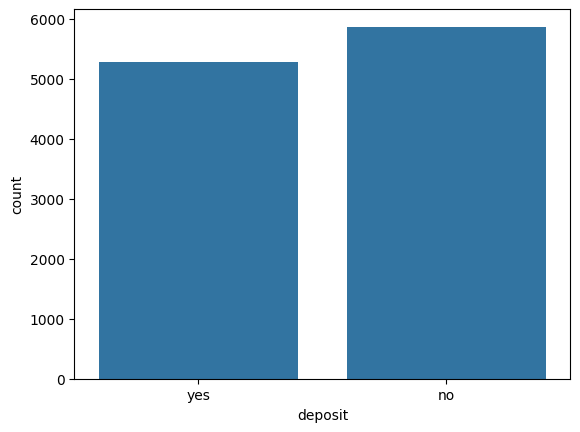

In [17]:
# Countplot

sns.countplot(data=df,x='deposit')
plt.show()

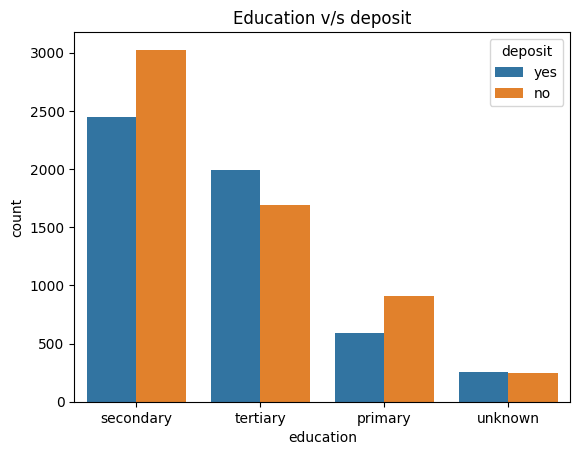

In [18]:
plt.title('Education v/s deposit')
sns.countplot(x = 'education', hue = 'deposit', data = df)
plt.show()

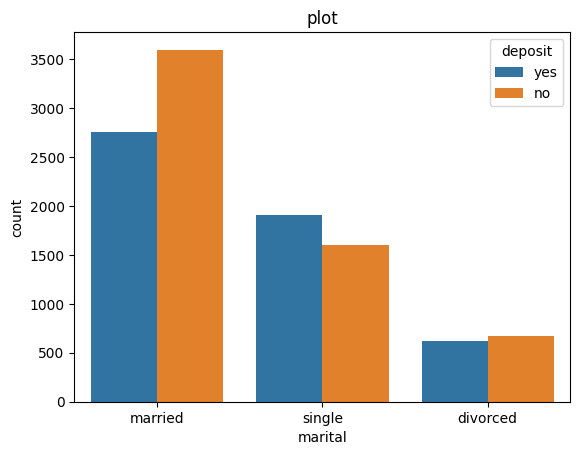

In [19]:
plt.title('plot')
sns.countplot(x = 'marital', hue = 'deposit', data = df)
plt.show()

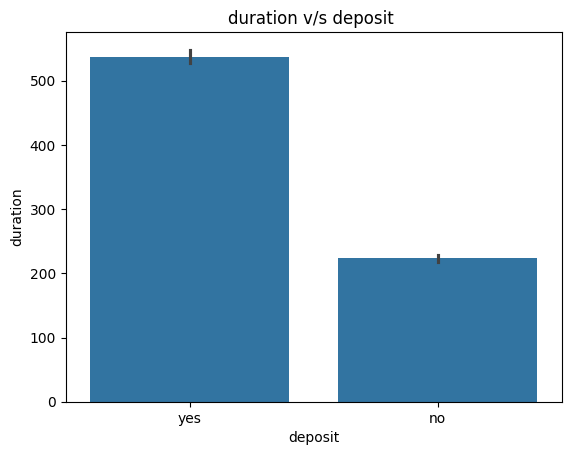

In [20]:
# Barplot
plt.title('duration v/s deposit ')
sns.barplot(x='deposit',y='duration',data=df)
plt.show()

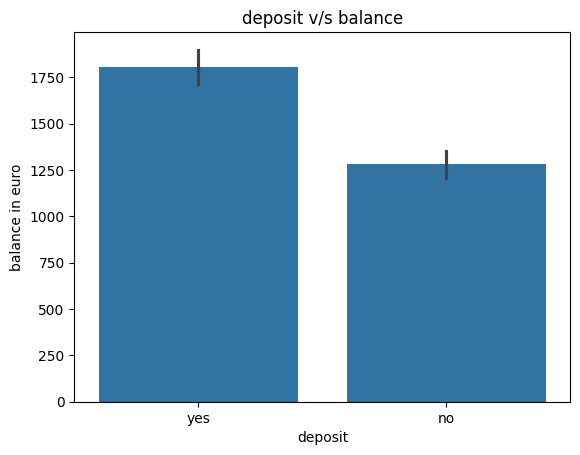

In [21]:
plt.title('deposit v/s balance')
sns.barplot(x='deposit',y='balance in euro',data=df)
plt.show()

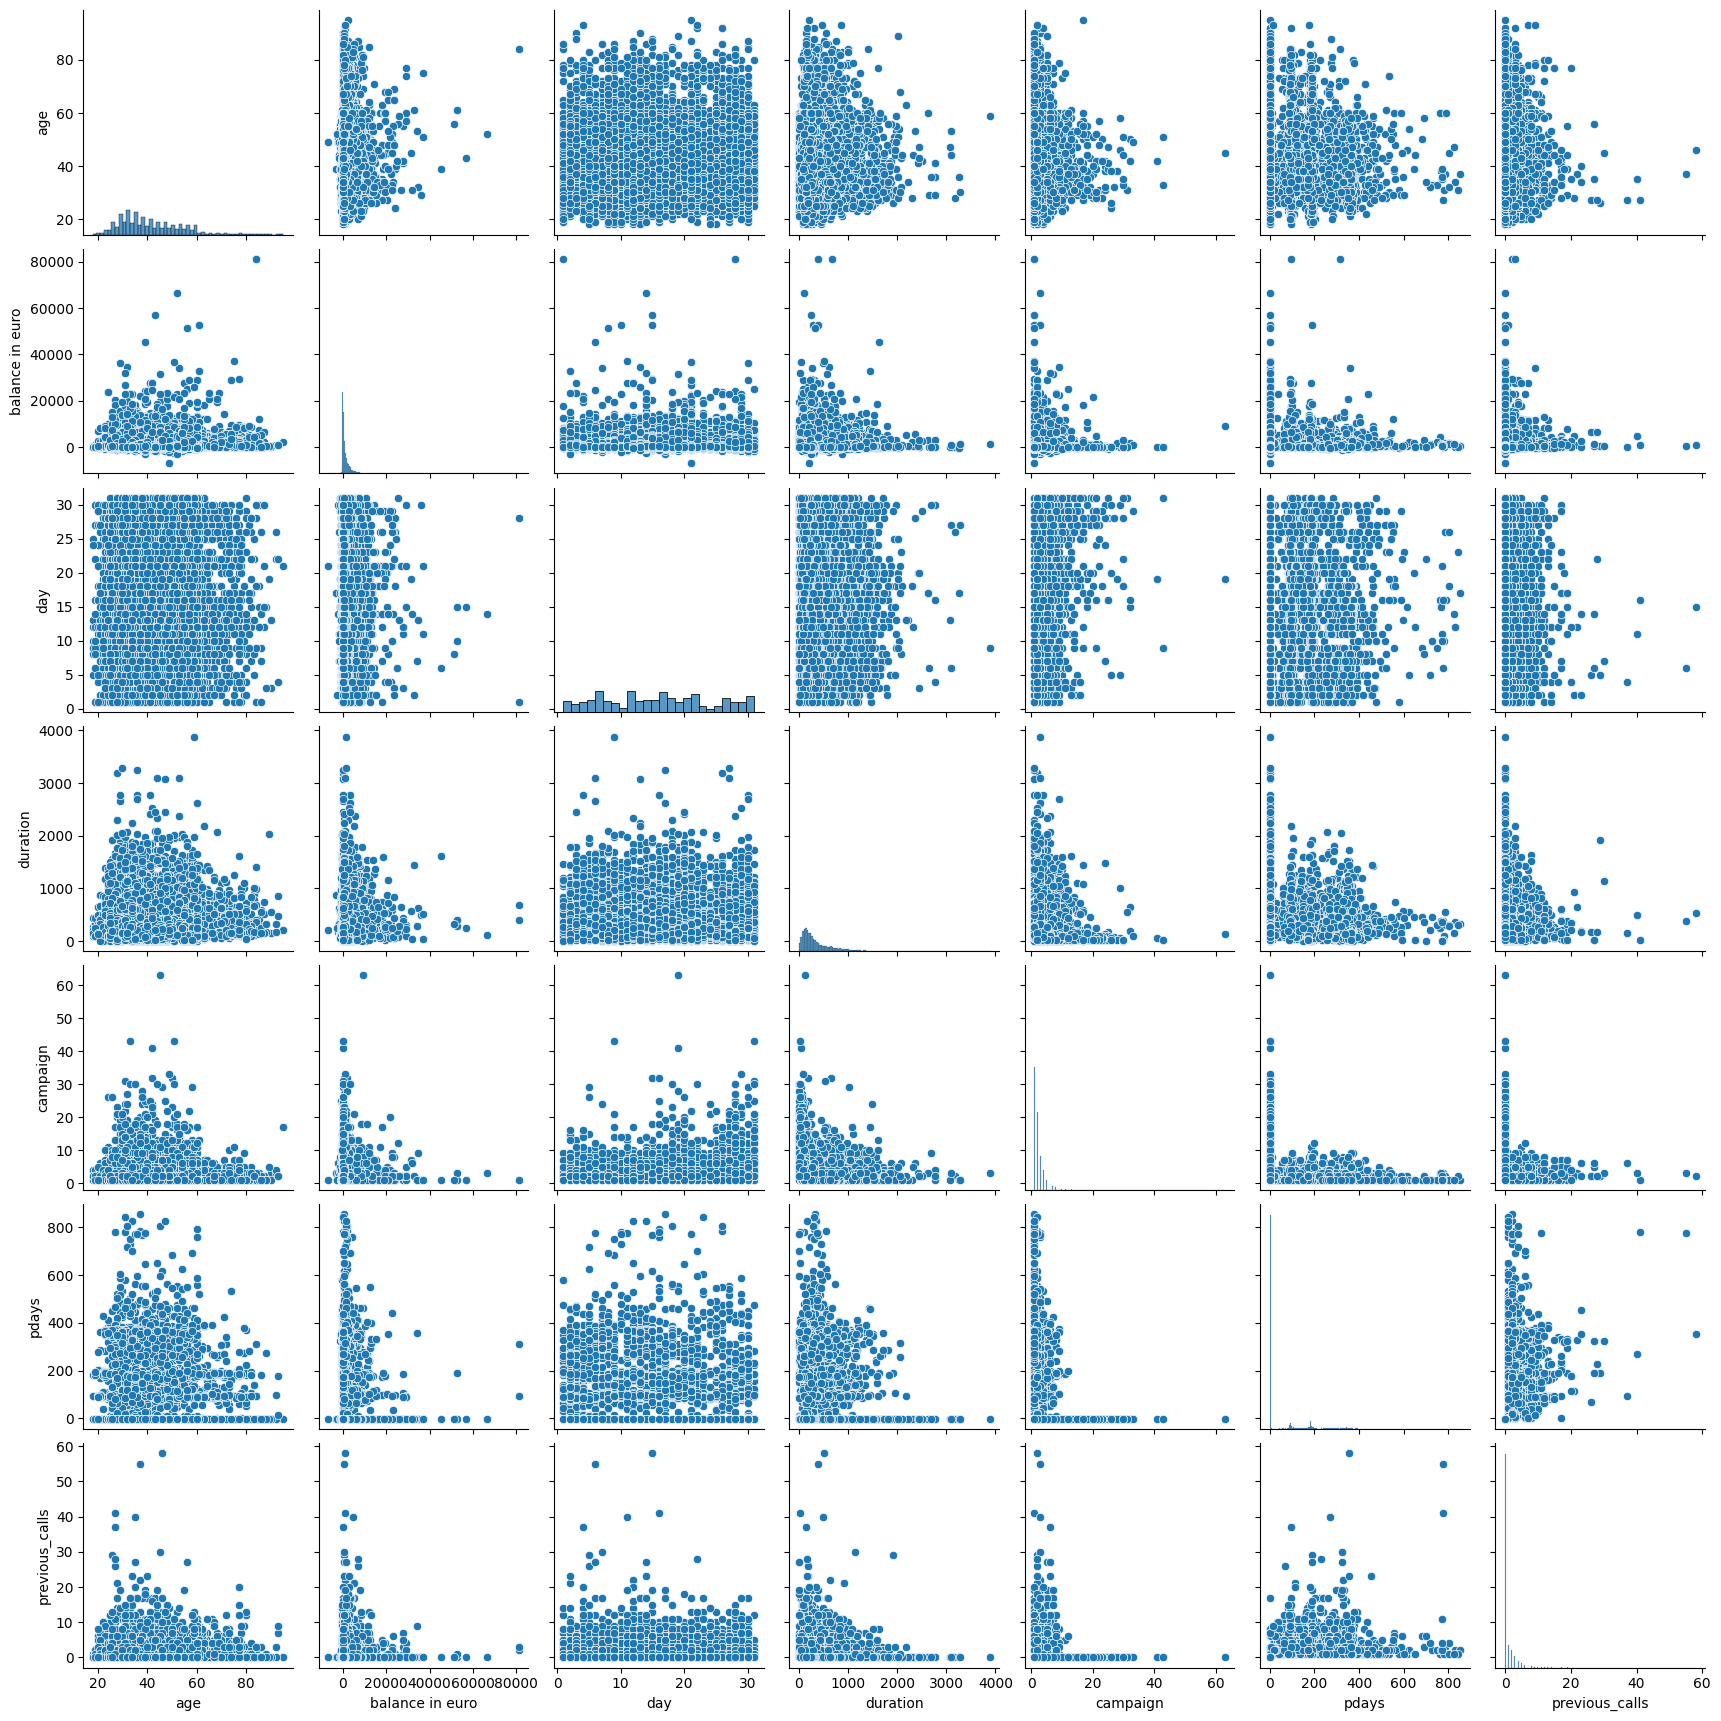

In [22]:
sns.pairplot(df)

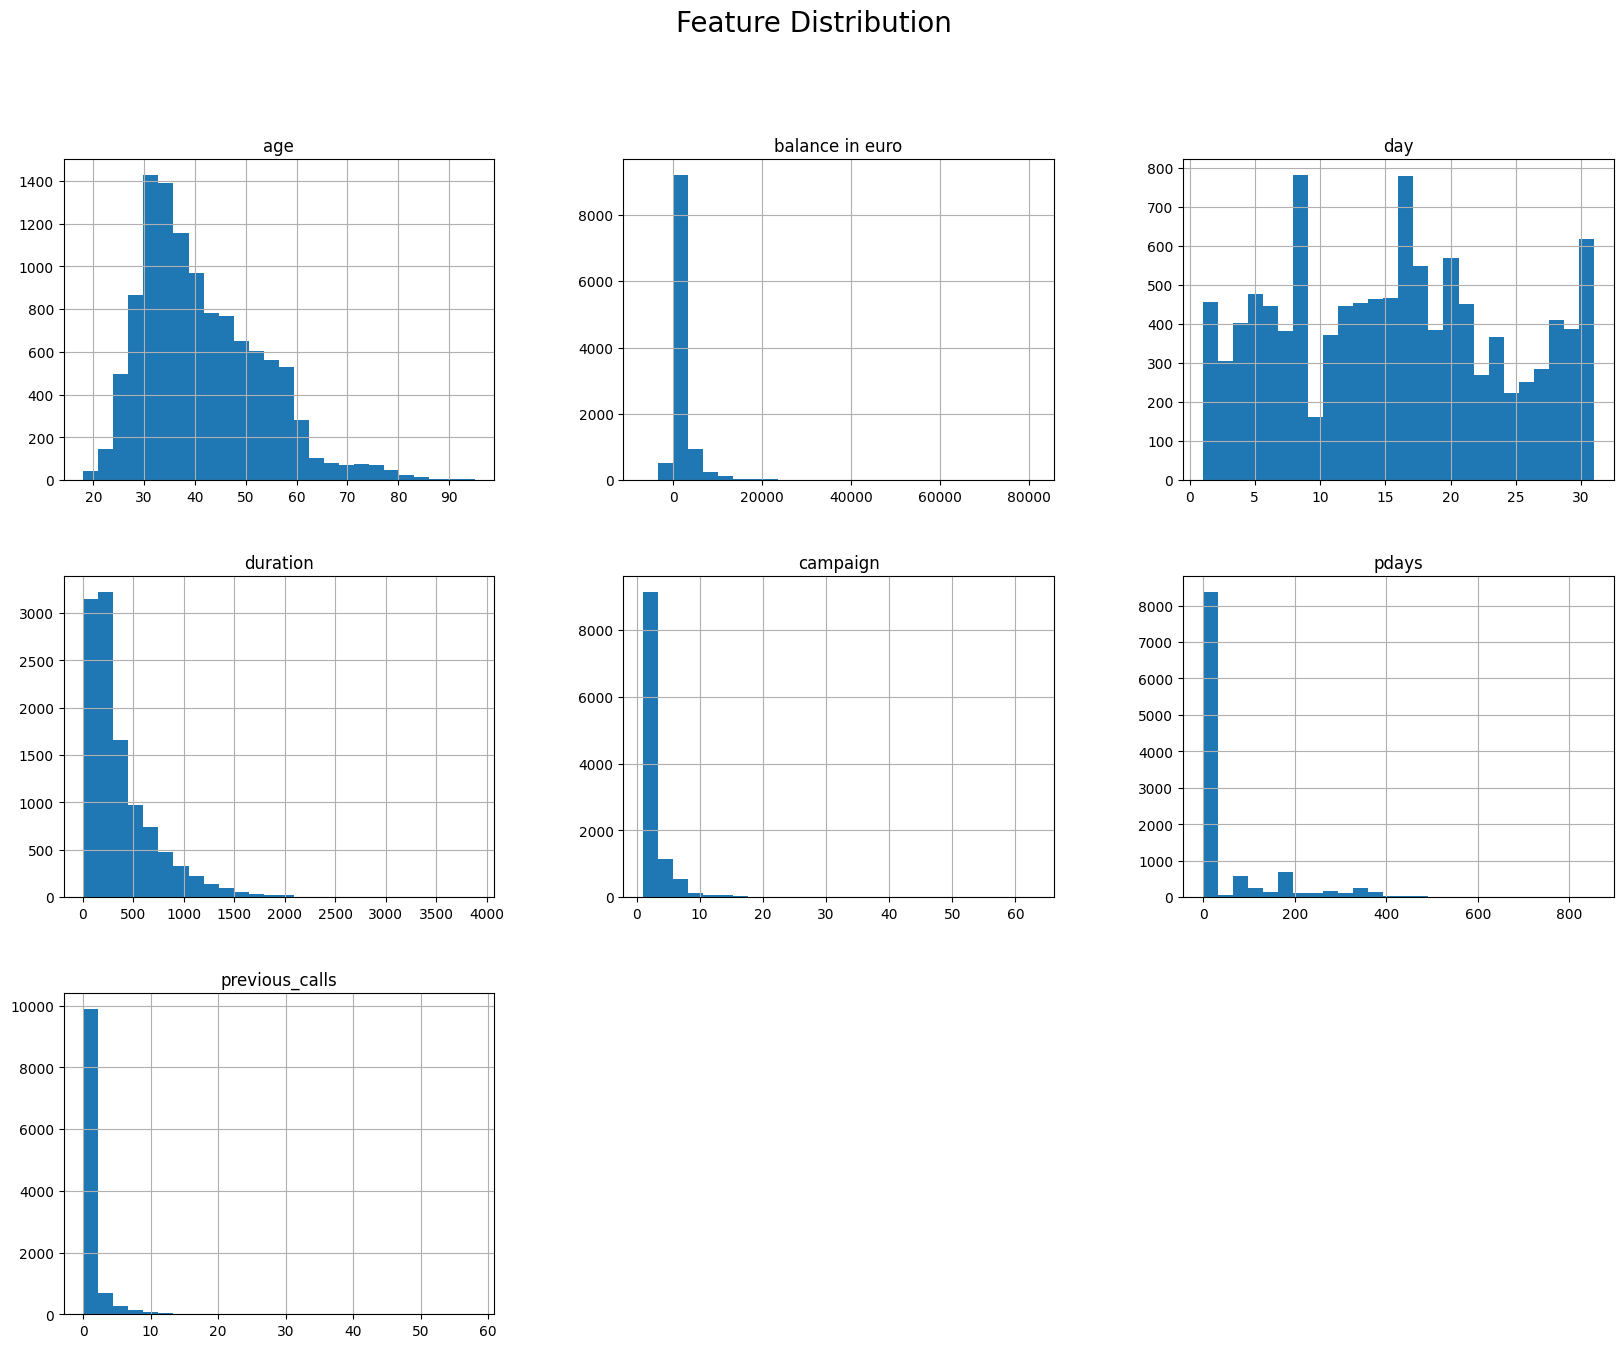

In [23]:
# Histogram

df.hist(figsize=(20, 15), bins=26)
plt.suptitle("Feature Distribution", fontsize=20)
plt.show()

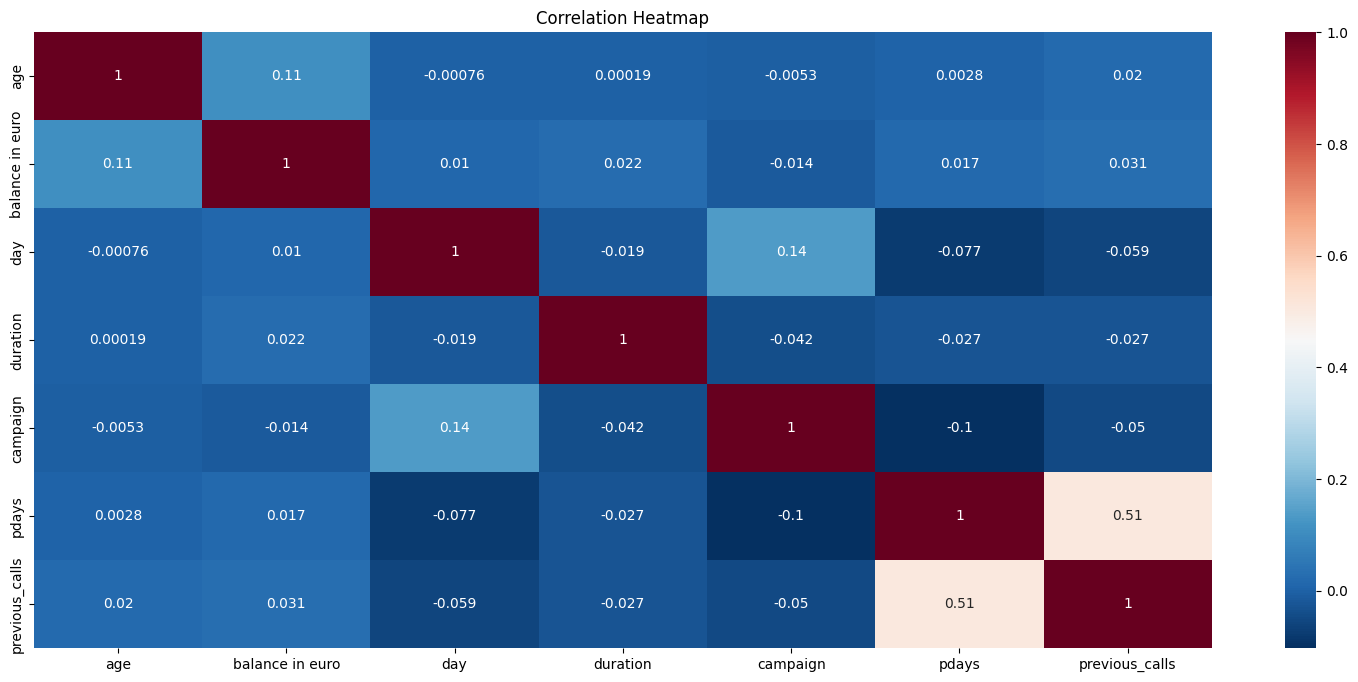

In [24]:
# Correlation HEATMAP

plt.figure(figsize=(19,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='RdBu_r')
plt.title("Correlation Heatmap")
plt.show()

# PREPROCESSING

In [25]:
from sklearn.preprocessing import LabelEncoder

In [26]:
le=LabelEncoder()
df['job'] = le.fit_transform(df['job'])
df['credit_default'] = le.fit_transform(df['credit_default'])
df['personal loan'] = le.fit_transform(df['personal loan'])
df['contact'] = le.fit_transform(df['contact'])
df['deposit'] = le.fit_transform(df['deposit'])
df['month'] = le.fit_transform(df['month'])

In [27]:
le1=LabelEncoder()
df['housing loan'] = le1.fit_transform(df['housing loan'])

In [28]:
le2=LabelEncoder()
df['poutcome'] = le2.fit_transform(df['poutcome'])

In [29]:
importance_map = {'married': 1, 'divorced': 2, 'single': 0}
df['marital'] = df['marital'].map(importance_map)

In [30]:
importance_map = {'unknown': 0, 'primary': 1, 'secondary': 2,'tertiary':3}
df['education'] = df['education'].map(importance_map)

In [31]:
df

,age,job,marital,education,credit_default,balance in euro,housing loan,personal loan,contact,day,month,duration,campaign,pdays,previous_calls,poutcome,deposit
0,59,0,1,2,0,2343,1,0,2,5,8,1042,1,-1,0,3,1
1,56,0,1,2,0,45,0,0,2,5,8,1467,1,-1,0,3,1
2,41,9,1,2,0,1270,1,0,2,5,8,1389,1,-1,0,3,1
3,55,7,1,2,0,2476,1,0,2,5,8,579,1,-1,0,3,1
4,54,0,1,3,0,184,0,0,2,5,8,673,2,-1,0,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,33,1,0,1,0,1,1,0,0,20,0,257,1,-1,0,3,0
11158,39,7,1,2,0,733,0,0,2,16,6,83,4,-1,0,3,0
11159,32,9,0,2,0,29,0,0,0,19,1,156,2,-1,0,3,0
11160,43,9,1,2,0,0,0,1,0,8,8,9,2,172,5,0,0


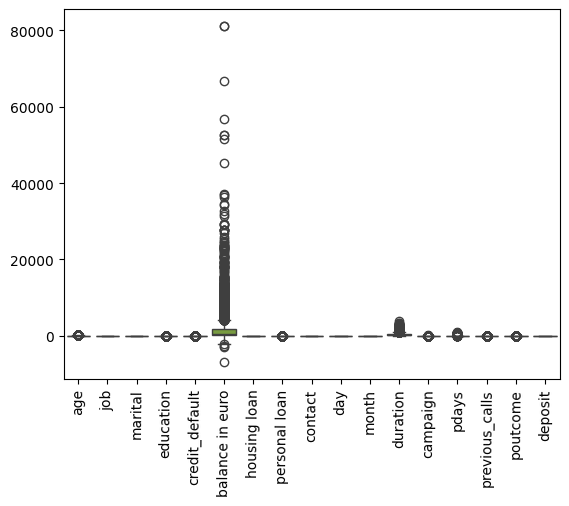

In [32]:
sns.boxplot(df)
plt.xticks(rotation=89.5)
plt.show()

In [33]:
features_to_cap = ['age','education','credit_default','balance in euro','personal loan','duration','campaign','pdays','previous_calls','poutcome']

for feature in features_to_cap:
   
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    
  
    upper_cap = Q3 + 1.5 * IQR
    lower_cap = Q1 - 1.5 * IQR
    
   
    df[feature] = np.where(df[feature] > upper_cap, upper_cap, df[feature])
    

    df[feature] = np.where(df[feature] < lower_cap, lower_cap, df[feature])

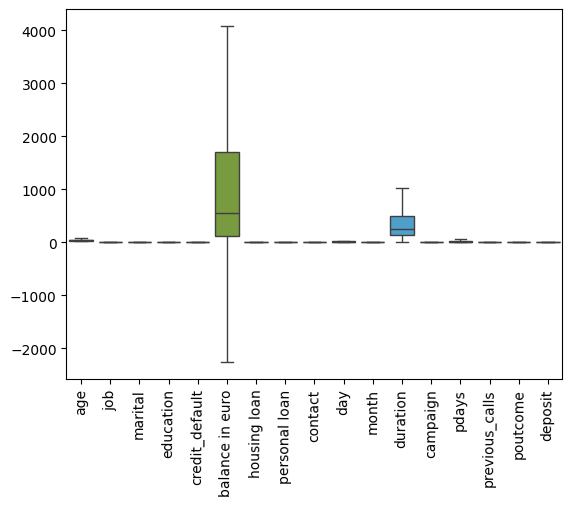

In [34]:
sns.boxplot(df)
plt.xticks(rotation=89.5)
plt.show()

In [35]:
x = df.drop('deposit', axis=1)
y = df['deposit']

In [36]:
x

,age,job,marital,education,credit_default,balance in euro,housing loan,personal loan,contact,day,month,duration,campaign,pdays,previous_calls,poutcome
0,59.0,0,1,2.0,0.0,2343.0,1,0.0,2,5,8,1033.0,1.0,-1.000,0.0,3.0
1,56.0,0,1,2.0,0.0,45.0,0,0.0,2,5,8,1033.0,1.0,-1.000,0.0,3.0
2,41.0,9,1,2.0,0.0,1270.0,1,0.0,2,5,8,1033.0,1.0,-1.000,0.0,3.0
3,55.0,7,1,2.0,0.0,2476.0,1,0.0,2,5,8,579.0,1.0,-1.000,0.0,3.0
4,54.0,0,1,3.0,0.0,184.0,0,0.0,2,5,8,673.0,2.0,-1.000,0.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,33.0,1,0,1.0,0.0,1.0,1,0.0,0,20,0,257.0,1.0,-1.000,0.0,3.0
11158,39.0,7,1,2.0,0.0,733.0,0,0.0,2,16,6,83.0,4.0,-1.000,0.0,3.0
11159,32.0,9,0,2.0,0.0,29.0,0,0.0,0,19,1,156.0,2.0,-1.000,0.0,3.0
11160,43.0,9,1,2.0,0.0,0.0,0,0.0,0,8,8,9.0,2.0,53.375,2.5,0.5


In [37]:
y

0        1
1        1
2        1
3        1
4        1
        ..
11157    0
11158    0
11159    0
11160    0
11161    0
Name: deposit, Length: 11162, dtype: int64

In [38]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x=sc.fit_transform(x)

In [39]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.30, random_state=42)

In [40]:
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

In [41]:
from imblearn.over_sampling import SMOTE
from collections import Counter

print("Before SMOTE:", Counter(y_train))

sm = SMOTE(random_state=42)
x_train, y_train = sm.fit_resample(x_train, y_train)

print("After SMOTE:", Counter(y_train))

Before SMOTE: Counter({0: 4131, 1: 3682})
After SMOTE: Counter({0: 4131, 1: 4131})


# LOGISTIC REGRESSION

In [42]:
from sklearn.linear_model import LogisticRegression

In [43]:
lr=LogisticRegression()
lr.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [44]:
lr_train = lr.score(x_train, y_train)
lr_test = lr.score(x_test, y_test)

In [45]:
lr_train

0.8038005325587025

In [46]:
lr_test

0.7960585249328158

In [47]:
y_pred=lr.predict(x_test)
y_pred

array([0, 1, 1, ..., 0, 0, 1], shape=(3349,))

In [48]:
from sklearn.metrics import classification_report,ConfusionMatrixDisplay

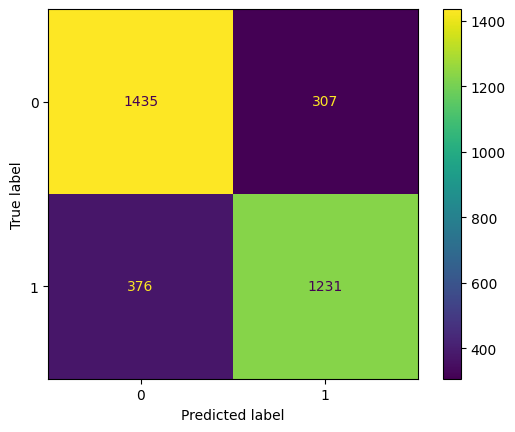

In [49]:
print(ConfusionMatrixDisplay.from_predictions(y_test,y_pred))

In [50]:
print('CR:',classification_report(y_test,y_pred))

CR:               precision    recall  f1-score   support

           0       0.79      0.82      0.81      1742
           1       0.80      0.77      0.78      1607

    accuracy                           0.80      3349
   macro avg       0.80      0.79      0.80      3349
weighted avg       0.80      0.80      0.80      3349



# DECISION TREE

In [51]:
from sklearn.tree import DecisionTreeClassifier

In [52]:
dt = DecisionTreeClassifier(class_weight='balanced',
    max_depth=5, 
    random_state=42
)

dt.fit(x_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


In [53]:
dt_train = dt.score(x_train, y_train)
dt_test = dt.score(x_test, y_test)

In [54]:
dt_train

0.8162672476397966

In [55]:
dt_test

0.8091967751567632

In [56]:
y_pred=dt.predict(x_test)
y_pred

array([0, 1, 1, ..., 0, 0, 1], shape=(3349,))

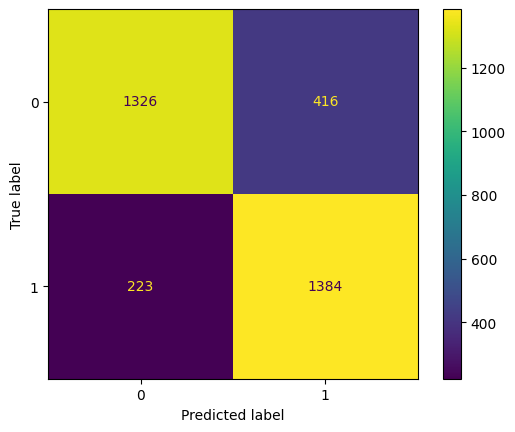

In [57]:
print(ConfusionMatrixDisplay.from_predictions(y_test,y_pred))

In [58]:
print('CR:',classification_report(y_test,y_pred))

CR:               precision    recall  f1-score   support

           0       0.86      0.76      0.81      1742
           1       0.77      0.86      0.81      1607

    accuracy                           0.81      3349
   macro avg       0.81      0.81      0.81      3349
weighted avg       0.81      0.81      0.81      3349



# RANDOM FOREST

In [59]:
from sklearn.ensemble import RandomForestClassifier

In [60]:
rf=RandomForestClassifier(n_estimators=80,random_state=88,max_depth=7)
rf.fit(x_train,y_train)

,n_estimators,80
,criterion,'gini'
,max_depth,7
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [61]:
rf_train = rf.score(x_train, y_train)
rf_test = rf.score(x_test, y_test)

In [62]:
rf_train

0.8537884289518276

In [63]:
rf_test

0.8205434458047178

In [64]:
y_pred=rf.predict(x_test)
y_pred

array([1, 1, 1, ..., 0, 0, 1], shape=(3349,))

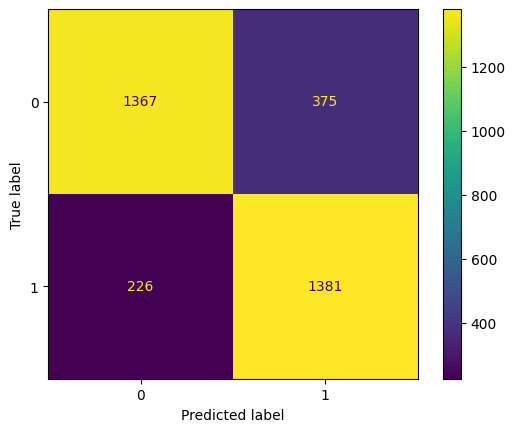

In [65]:
print(ConfusionMatrixDisplay.from_predictions(y_test,y_pred))

# KNN

In [66]:
from sklearn.neighbors import KNeighborsClassifier

In [67]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.30,random_state=60)

In [68]:
knn= KNeighborsClassifier()
knn.fit(x_train,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [69]:
knn_train = knn.score(x_train, y_train)
knn_test = knn.score(x_test, y_test)

In [70]:
knn_train

0.8456418789197492

In [71]:
knn_test

0.7921767691848313

In [72]:
y_pred=knn.predict(x_test)
y_pred

array([0, 0, 0, ..., 0, 1, 0], shape=(3349,))

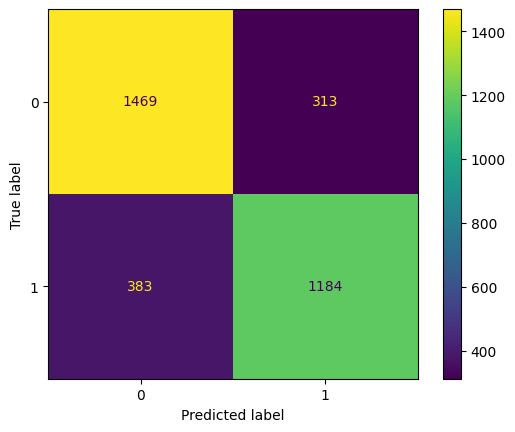

In [73]:
print(ConfusionMatrixDisplay.from_predictions(y_test,y_pred))

In [74]:
print('CR:',classification_report(y_test,y_pred))

CR:               precision    recall  f1-score   support

           0       0.79      0.82      0.81      1782
           1       0.79      0.76      0.77      1567

    accuracy                           0.79      3349
   macro avg       0.79      0.79      0.79      3349
weighted avg       0.79      0.79      0.79      3349



# NAIVE BAYES

In [75]:
from sklearn.naive_bayes import GaussianNB
nb=GaussianNB()

In [76]:
nb.fit(x_train,y_train)

,priors,None
,var_smoothing,1e-09


In [77]:
nb_train = nb.score(x_train, y_train)
nb_test = nb.score(x_test, y_test)

In [78]:
nb_train

0.7507999488032766

In [79]:
nb_test

0.7524634219169901

In [80]:
y_pred=nb.predict(x_test)
y_pred

array([0, 0, 0, ..., 1, 1, 1], shape=(3349,))

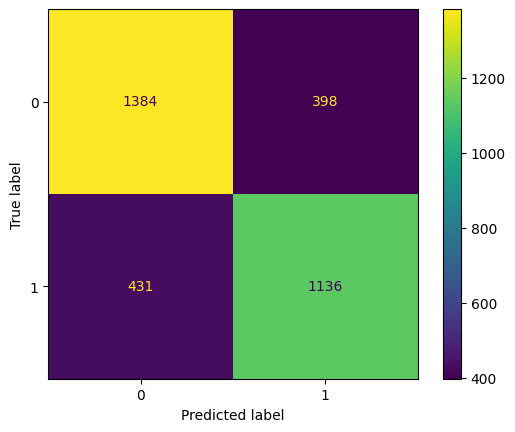

In [81]:
print(ConfusionMatrixDisplay.from_predictions(y_test,y_pred))

In [82]:
print('CR:',classification_report(y_test,y_pred))

CR:               precision    recall  f1-score   support

           0       0.76      0.78      0.77      1782
           1       0.74      0.72      0.73      1567

    accuracy                           0.75      3349
   macro avg       0.75      0.75      0.75      3349
weighted avg       0.75      0.75      0.75      3349



# SUPPORT VECTOR MACHINE

In [83]:
from sklearn.svm import SVC

LINEAR KERNAL

In [84]:
svm=SVC(kernel='linear')

In [85]:
svm.fit(x_train,y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [86]:
svm_test=svm.score(x_test,y_test)
svm_train=svm.score(x_train,y_train)

In [87]:
svm_train

0.7955970817867657

In [88]:
svm_test

0.8154673036727381

POLYNOMIAL KERNAL

In [89]:
svm1 = SVC(kernel='poly')
svm1.fit(x_train, y_train)

,C,1.0
,kernel,'poly'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [90]:
svm1.score(x_train,y_train)

0.8288749520030718

In [91]:
svm1.score(x_test,y_test)

0.820244849208719

SIGMOID

In [92]:
svm_sig=SVC(kernel='sigmoid')
svm_sig.fit(x_train,y_train)

,C,1.0
,kernel,'sigmoid'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [93]:
svm_sig.score(x_train,y_train)

0.6870600281581979

In [94]:
svm_sig.score(x_test,y_test)

0.6903553299492385

# ADABOOST

In [95]:
from sklearn.ensemble import AdaBoostClassifier

In [96]:
adaBoost=AdaBoostClassifier(n_estimators=50,learning_rate=0.3,random_state=1)

In [97]:
adaBoost.fit(x_train,y_train)

,estimator,None
,n_estimators,50
,learning_rate,0.3
,algorithm,'deprecated'
,random_state,1


In [98]:
ada_train = adaBoost.score(x_train, y_train)
ada_test = adaBoost.score(x_test, y_test)

In [99]:
ada_train

0.7920133111480865

In [100]:
ada_test

0.7981487011048074

In [101]:
y_pred=adaBoost.predict(x_test)
y_pred

array([0, 0, 0, ..., 1, 1, 0], shape=(3349,))

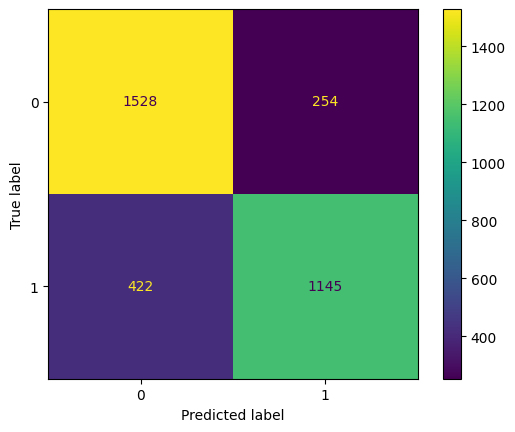

In [102]:
ConfusionMatrixDisplay.from_predictions(y_test,y_pred)

# GRADIENT BOOST

In [103]:
from sklearn.ensemble import GradientBoostingClassifier

In [104]:
gcb=GradientBoostingClassifier(n_estimators=100,learning_rate=0.03,random_state=42)
gcb.fit(x_train,y_train)

,loss,'log_loss'
,learning_rate,0.03
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [105]:
gcb_train = gcb.score(x_train, y_train)
gcb_test = gcb.score(x_test, y_test)

In [106]:
gcb_train

0.8258031485984897

In [107]:
gcb_test

0.8277097641086891

In [108]:
y_pred=gcb.predict(x_test)
y_pred

array([0, 0, 0, ..., 1, 1, 0], shape=(3349,))

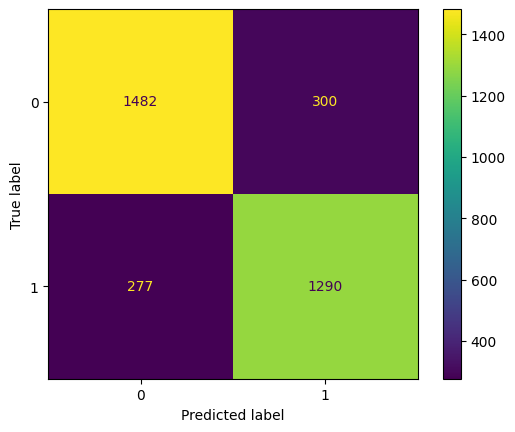

In [109]:
ConfusionMatrixDisplay.from_predictions(y_test,y_pred)

In [110]:
print('CR:',classification_report(y_test,y_pred))

CR:               precision    recall  f1-score   support

           0       0.84      0.83      0.84      1782
           1       0.81      0.82      0.82      1567

    accuracy                           0.83      3349
   macro avg       0.83      0.83      0.83      3349
weighted avg       0.83      0.83      0.83      3349



# XGBOOST

In [111]:
from xgboost import XGBClassifier

In [112]:
xgb=XGBClassifier(max_depth=3,learning_rate=0.03,n_estimators=200,random_state=66)
xgb.fit(x_train,y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [113]:
xgb_train = xgb.score(x_train, y_train)
xgb_test = xgb.score(x_test, y_test)

In [114]:
xgb_train

0.8435940099833611

In [115]:
xgb_test

0.8399522245446401

In [116]:
y_pred=xgb.predict(x_test)
y_pred

array([0, 0, 0, ..., 1, 1, 0], shape=(3349,))

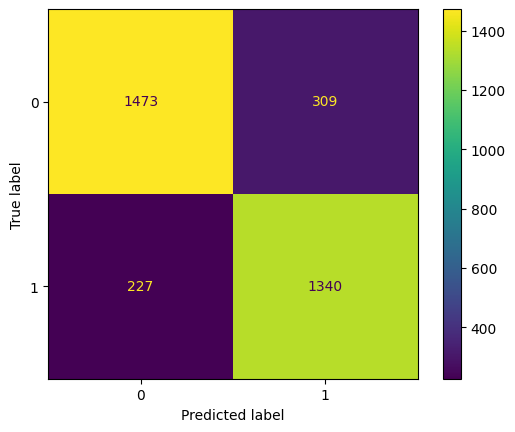

In [117]:
ConfusionMatrixDisplay.from_predictions(y_test,y_pred)

In [118]:
print('CR:',classification_report(y_test,y_pred))

CR:               precision    recall  f1-score   support

           0       0.87      0.83      0.85      1782
           1       0.81      0.86      0.83      1567

    accuracy                           0.84      3349
   macro avg       0.84      0.84      0.84      3349
weighted avg       0.84      0.84      0.84      3349



In [119]:
tb = pd.DataFrame()
tb['model'] = ['lr','dt','rf','knn','svm','nb','adaBoost','gcb','xgb']
tb['test_accuracy'] = [lr_test, dt_test, rf_test, knn_test, svm_test, nb_test, ada_test, gcb_test, xgb_test]
tb['train_accuracy'] = [lr_train, dt_train, rf_train, knn_train, svm_train, nb_train, ada_train, gcb_train, xgb_train]
tb

,model,test_accuracy,train_accuracy
0,lr,0.796059,0.803801
1,dt,0.809197,0.816267
2,rf,0.820543,0.853788
3,knn,0.792177,0.845642
4,svm,0.815467,0.795597
5,nb,0.752463,0.750800
6,adaBoost,0.798149,0.792013
7,gcb,0.827710,0.825803
8,xgb,0.839952,0.843594


# CROSS VALIDATION

In [120]:
from sklearn.model_selection import cross_val_score

In [121]:
cross_val_score(RandomForestClassifier(n_estimators=10),x,y,cv=5)


array([0.73085535, 0.70712047, 0.78897849, 0.83243728, 0.81317204])

In [122]:
cross_val_score(XGBClassifier(n_estimator=10),x,y,cv=5)


array([0.75638155, 0.7716077 , 0.81003584, 0.85215054, 0.83870968])

In [123]:
cross_val_score(GradientBoostingClassifier(n_estimators=10),x,y,cv=5)


array([0.78996865, 0.73891626, 0.73207885, 0.78405018, 0.78181004])

In [124]:
score=cross_val_score(GradientBoostingClassifier(n_estimators=10),x,y,cv=5)
np.average(score)

np.float64(0.7653647952591223)

In [125]:
score=cross_val_score(GradientBoostingClassifier(n_estimators=20),x,y,cv=10)
np.average(score)

np.float64(0.784355496513639)

# HYPERPARAMETER TUNING

In [126]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics  import accuracy_score

In [127]:
# LOGISTIC REGRESSION

ir_params={'C':[0.1,1,10]}
ir_grid=GridSearchCV(LogisticRegression(),ir_params,cv=5)
ir_grid.fit(x_train,y_train) 

,estimator,LogisticRegression()
,param_grid,"{'C': [0.1, 1, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [128]:
# DECISION TREE

dt_params={'max_depth':[2,4,6,None],'criterion':['gini','entropy']}
dt_grid=GridSearchCV(DecisionTreeClassifier(random_state=42),dt_params,cv=5)
dt_grid.fit(x_train,y_train)

,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [2, 4, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [129]:
# RANDOM FOREST

rf_params={'n_estimators':[10,50,100],'max_depth':[2,4,6,None]}
rf_grid=GridSearchCV(RandomForestClassifier(random_state=42),rf_params,cv=5)
rf_grid.fit(x_train,y_train)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [2, 4, ...], 'n_estimators': [10, 50, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [130]:
# KNN
knn_param = {
    'n_neighbors':range(1, 31), 
    'weights':['uniform','distance'], 
    'metric':['euclidean','manhattan','minkowski']  
}
knn_grid= GridSearchCV(knn,knn_param,cv=5,scoring='accuracy', n_jobs=-1)
knn_grid.fit(x_train,y_train)

,estimator,KNeighborsClassifier()
,param_grid,"{'metric': ['euclidean', 'manhattan', ...], 'n_neighbors': range(1, 31), 'weights': ['uniform', 'distance']}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,21


In [131]:
# GRADIENT BOOST

gb_param = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'min_samples_split': [2, 5]}
gb_grid = GridSearchCV(GradientBoostingClassifier(),gb_param,cv=5,scoring='accuracy',n_jobs=-1)
gb_grid.fit(x_train, y_train)

,estimator,GradientBoostingClassifier()
,param_grid,"{'learning_rate': [0.05, 0.1], 'max_depth': [3, 5], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,loss,'log_loss'


In [132]:
xgb_param = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'min_samples_split': [2, 5]}
xgb_grid = GridSearchCV(XGBClassifier(),xgb_param,cv=5,scoring='accuracy',n_jobs=-1)
xgb_grid.fit(x_train, y_train)

,estimator,"XGBClassifier...ree=None, ...)"
,param_grid,"{'learning_rate': [0.05, 0.1], 'max_depth': [3, 5], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'binary:logistic'


In [133]:
models = {'Logistic Regression': ir_grid,
          'Decision Tree': dt_grid,
          'Random Forest': rf_grid,
          'KNN':knn_grid,
          #'SVM': svm_grid,
          'GB':gb_grid, 
          'XGB':xgb_grid}
for name, grid in models.items():
    best_model = grid.best_estimator_
    y_pred = best_model.predict(x_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"{name}:")
    print(f"  Best Params: {grid.best_params_}")
    print(f"  Accuracy:{acc:.4f}\n")

Logistic Regression:
  Best Params: {'C': 0.1}
  Accuracy:0.8131

Decision Tree:
  Best Params: {'criterion': 'gini', 'max_depth': 6}
  Accuracy:0.8134

Random Forest:
  Best Params: {'max_depth': None, 'n_estimators': 100}
  Accuracy:0.8537

KNN:
  Best Params: {'metric': 'manhattan', 'n_neighbors': 21, 'weights': 'distance'}
  Accuracy:0.8140

GB:
  Best Params: {'learning_rate': 0.05, 'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 200}
  Accuracy:0.8567

XGB:
  Best Params: {'learning_rate': 0.1, 'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 200}
  Accuracy:0.8564



In [134]:
# Access the best model
best_gcb_model =xgb_grid.best_estimator_
y_pred = best_gcb_model.predict(x_test)

In [135]:
print(best_gcb_model)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, min_samples_split=2,
              missing=nan, monotone_constraints=None, multi_strategy=None,
              n_estimators=200, n_jobs=None, ...)


In [136]:
scaler=StandardScaler()
model_input=['poutcome','housing loan','balance in euro','campaign','previous_calls']
X=df[model_input]
X_scaled=scaler.fit_transform(X)

In [137]:
best_gcb_model.fit(X_scaled,y)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


# joblib

In [138]:
import joblib
joblib.dump(best_gcb_model,'bank.pkl')

['bank.pkl']

In [139]:
joblib.dump(scaler,'scaler.pkl')

['scaler.pkl']

In [140]:
joblib.dump(le1,'le1.pkl')

['le1.pkl']

In [141]:
joblib.dump(le2,'le2.pkl')

['le2.pkl']